In [1]:
# Setup pipeline state so downstream cells run without NameError
import sqlite3
import numpy as np
import pandas as pd
import scipy.signal as signal
from scipy.signal import find_peaks
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

np.random.seed(42)
fs = 500
duration = 10

db_path = Path('../data/processed/neuro_genomic.db')
loaded_from = 'synthetic'

# Load ECG from DB when available
if db_path.exists():
    try:
        with sqlite3.connect(db_path) as conn:
            tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist()
            if 'raw_ecg' in tables:
                raw_df = pd.read_sql_query('SELECT * FROM raw_ecg', conn)
                if {'time_s', 'ch1', 'ch2'}.issubset(raw_df.columns):
                    t = raw_df['time_s'].values
                    ecg_signal = raw_df[['ch1', 'ch2']].to_numpy()
                    loaded_from = 'database: raw_ecg'
            elif 'separated_components' in tables:
                sep_df = pd.read_sql_query('SELECT * FROM separated_components', conn)
                if {'time_s', 'maternal_ecg', 'fetal_ecg'}.issubset(sep_df.columns):
                    t = sep_df['time_s'].values
                    maternal_ecg = sep_df['maternal_ecg'].values
                    fetal_ecg = sep_df['fetal_ecg'].values
                    mixed_ch1 = 0.7 * maternal_ecg + 0.5 * fetal_ecg + 0.4 * np.random.randn(len(t))
                    mixed_ch2 = 0.6 * maternal_ecg + 0.6 * fetal_ecg + 0.3 * np.random.randn(len(t))
                    ecg_signal = np.column_stack([mixed_ch1, mixed_ch2])
                    loaded_from = 'database: separated_components (remixed)'
    except Exception:
        pass

# Synthetic fallback
if loaded_from == 'synthetic':
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)
    maternal_ecg = 5 * np.sin(2 * np.pi * 1.2 * t) + 0.3 * np.random.randn(len(t))
    fetal_ecg = 2.5 * np.sin(2 * np.pi * 2.4 * t + np.pi / 4) + 0.2 * np.random.randn(len(t))
    mixed_ch1 = 0.7 * maternal_ecg + 0.5 * fetal_ecg + 0.4 * np.random.randn(len(t))
    mixed_ch2 = 0.6 * maternal_ecg + 0.6 * fetal_ecg + 0.3 * np.random.randn(len(t))
    ecg_signal = np.column_stack([mixed_ch1, mixed_ch2])

# Preprocessing
lowcut, highcut, filter_order = 0.5, 40, 4
nyq = fs / 2
b, a = signal.butter(filter_order, [lowcut / nyq, highcut / nyq], btype='band')
filtered_ch1 = signal.filtfilt(b, a, ecg_signal[:, 0])
filtered_ch2 = signal.filtfilt(b, a, ecg_signal[:, 1])
filtered_signal = np.column_stack([filtered_ch1, filtered_ch2])

# ICA
ica = FastICA(n_components=2, max_iter=500, random_state=42, whiten='unit-variance')
independent_components = ica.fit_transform(filtered_signal)
component_1 = independent_components[:, 0]
component_2 = independent_components[:, 1]

# R-peak + HRV helper

def extract_heart_rate_features(ecg_signal, sampling_rate, component_name='Component'):
    signal_abs = np.abs(ecg_signal)
    threshold = np.mean(signal_abs) + 2 * np.std(signal_abs)
    peaks, _ = find_peaks(signal_abs, height=threshold, distance=sampling_rate * 0.4)
    if len(peaks) < 2:
        return None, np.array([])
    rr_intervals = np.diff(peaks) / sampling_rate * 1000
    heart_rate = 60 / (np.mean(rr_intervals) / 1000)
    hrv_features = {
        'component': component_name,
        'num_beats': len(peaks),
        'heart_rate_mean': heart_rate,
        'heart_rate_std': np.std(60 / (rr_intervals / 1000)),
        'rr_interval_mean': np.mean(rr_intervals),
        'rr_interval_std': np.std(rr_intervals),
        'rmssd': np.sqrt(np.mean(np.diff(rr_intervals) ** 2)),
        'pnn50': 100 * np.sum(np.abs(np.diff(rr_intervals)) > 50) / len(rr_intervals),
    }
    return hrv_features, peaks

features_ic1, peaks_ic1 = extract_heart_rate_features(component_1, fs, 'IC1 (Maternal)')
features_ic2, peaks_ic2 = extract_heart_rate_features(component_2, fs, 'IC2 (Fetal)')

print(f'Pipeline initialized from: {loaded_from}')
print(f'ECG shape: {ecg_signal.shape}, filtered shape: {filtered_signal.shape}')

Pipeline initialized from: synthetic
ECG shape: (5000, 2), filtered shape: (5000, 2)


In [2]:
# Heart rate feature extraction from separated ECG components
from scipy.signal import find_peaks

def extract_heart_rate_features(ecg_signal, sampling_rate, component_name="Component"):
    # Adaptive threshold R-peak detection
    signal_abs = np.abs(ecg_signal)
    threshold = np.mean(signal_abs) + 2 * np.std(signal_abs)
    peaks, _ = find_peaks(signal_abs, height=threshold, distance=sampling_rate * 0.4)

    if len(peaks) < 2:
        return None

    # RR intervals in ms
    rr_intervals = np.diff(peaks) / sampling_rate * 1000
    heart_rate = 60 / (np.mean(rr_intervals) / 1000)

    # Time-domain HRV features
    hrv_features = {
        'component': component_name,
        'num_beats': len(peaks),
        'heart_rate_mean': heart_rate,
        'heart_rate_std': np.std(60 / (rr_intervals / 1000)),
        'rr_interval_mean': np.mean(rr_intervals),
        'rr_interval_std': np.std(rr_intervals),
        'rmssd': np.sqrt(np.mean(np.diff(rr_intervals)**2)),
        'pnn50': 100 * np.sum(np.abs(np.diff(rr_intervals)) > 50) / len(rr_intervals),
    }
    return hrv_features, peaks

features_ic1, peaks_ic1 = extract_heart_rate_features(component_1, fs, "IC1 (Maternal)")
features_ic2, peaks_ic2 = extract_heart_rate_features(component_2, fs, "IC2 (Fetal)")

print("IC1 (Maternal):")
print(f"  HR: {features_ic1['heart_rate_mean']:.1f} bpm  RMSSD: {features_ic1['rmssd']:.2f} ms  pNN50: {features_ic1['pnn50']:.1f}%")
print("IC2 (Fetal):")
print(f"  HR: {features_ic2['heart_rate_mean']:.1f} bpm  RMSSD: {features_ic2['rmssd']:.2f} ms  pNN50: {features_ic2['pnn50']:.1f}%")

IC1 (Maternal):
  HR: 48.1 bpm  RMSSD: 1294.26 ms  pNN50: 85.7%
IC2 (Fetal):
  HR: 109.4 bpm  RMSSD: 232.32 ms  pNN50: 64.7%


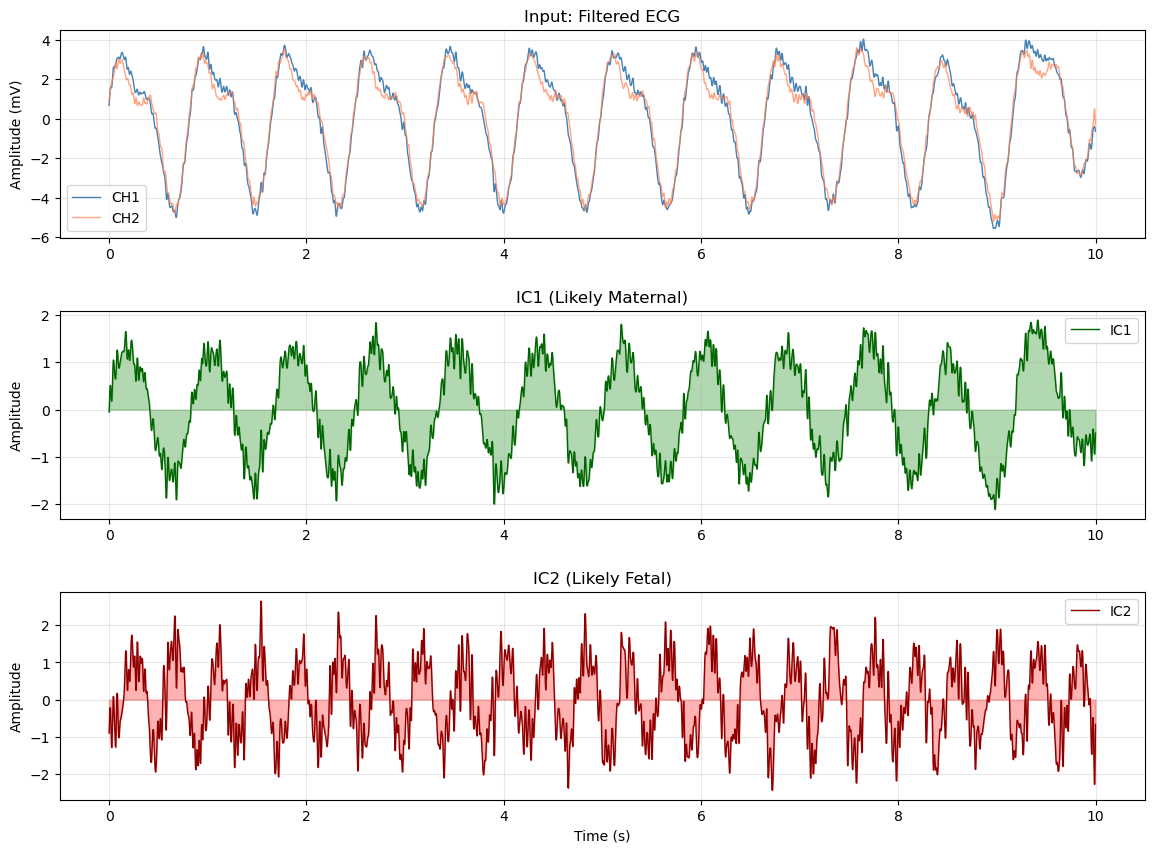

In [3]:
# Plot separated ICA components
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(t, filtered_signal[:,0], linewidth=1, label='CH1', color='steelblue')
ax1.plot(t, filtered_signal[:,1], linewidth=1, label='CH2', color='coral', alpha=0.7)
ax1.set_ylabel('Amplitude (mV)'); ax1.set_title('Input: Filtered ECG')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1, :])
ax2.plot(t, component_1, linewidth=1, color='darkgreen', label='IC1')
ax2.fill_between(t, component_1, alpha=0.3, color='green')
ax2.set_ylabel('Amplitude'); ax2.set_title('IC1 (Likely Maternal)')
ax2.legend(); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[2, :])
ax3.plot(t, component_2, linewidth=1, color='darkred', label='IC2')
ax3.fill_between(t, component_2, alpha=0.3, color='red')
ax3.set_xlabel('Time (s)'); ax3.set_ylabel('Amplitude'); ax3.set_title('IC2 (Likely Fetal)')
ax3.legend(); ax3.grid(True, alpha=0.3)

plt.savefig('../results/plots/03_ica_signal_separation.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# FastICA — blind source separation into 2 components (maternal + fetal)
n_components = 2
ica = FastICA(n_components=n_components, max_iter=500, random_state=42, whiten='unit-variance')
independent_components = ica.fit_transform(filtered_signal)

component_1 = independent_components[:,0]
component_2 = independent_components[:,1]

mixing_matrix = ica.mixing_
print(f"ICA complete — {n_components} components extracted")
print(f"Mixing: CH1 = {mixing_matrix[0,0]:.3f}*IC1 + {mixing_matrix[0,1]:.3f}*IC2")
print(f"        CH2 = {mixing_matrix[1,0]:.3f}*IC1 + {mixing_matrix[1,1]:.3f}*IC2")

ICA complete — 2 components extracted
Mixing: CH1 = 2.510*IC1 + -0.842*IC2
        CH2 = 2.133*IC1 + -1.082*IC2


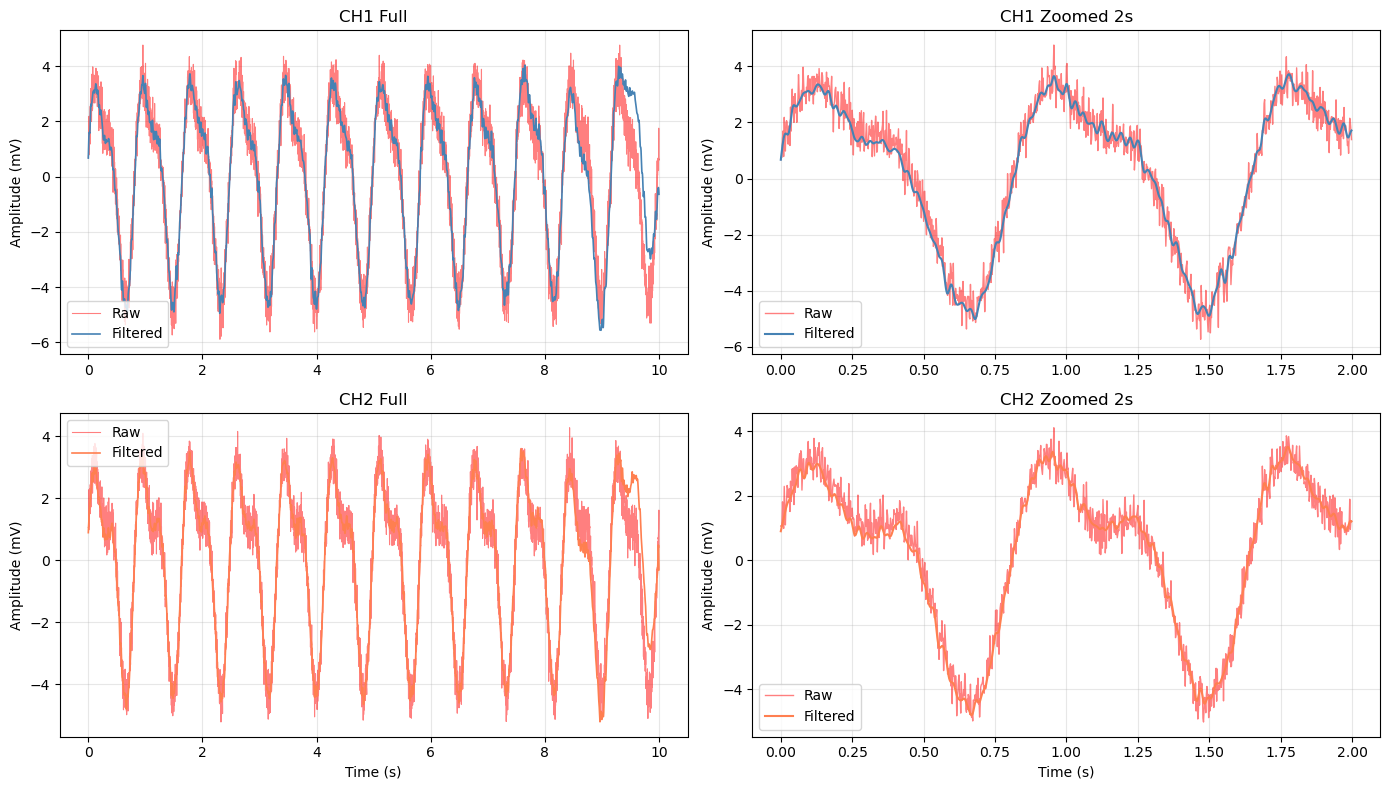

In [5]:
# Raw vs filtered comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0,0].plot(t, ecg_signal[:,0], linewidth=0.8, color='red', alpha=0.5, label='Raw')
axes[0,0].plot(t, filtered_signal[:,0], linewidth=1.2, color='steelblue', label='Filtered')
axes[0,0].set_ylabel('Amplitude (mV)'); axes[0,0].set_title('CH1 Full')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)

idx = slice(0, int(fs * 2))
axes[0,1].plot(t[idx], ecg_signal[idx,0], linewidth=1, color='red', alpha=0.5, label='Raw')
axes[0,1].plot(t[idx], filtered_signal[idx,0], linewidth=1.5, color='steelblue', label='Filtered')
axes[0,1].set_ylabel('Amplitude (mV)'); axes[0,1].set_title('CH1 Zoomed 2s')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(t, ecg_signal[:,1], linewidth=0.8, color='red', alpha=0.5, label='Raw')
axes[1,0].plot(t, filtered_signal[:,1], linewidth=1.2, color='coral', label='Filtered')
axes[1,0].set_xlabel('Time (s)'); axes[1,0].set_ylabel('Amplitude (mV)'); axes[1,0].set_title('CH2 Full')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(t[idx], ecg_signal[idx,1], linewidth=1, color='red', alpha=0.5, label='Raw')
axes[1,1].plot(t[idx], filtered_signal[idx,1], linewidth=1.5, color='coral', label='Filtered')
axes[1,1].set_xlabel('Time (s)'); axes[1,1].set_ylabel('Amplitude (mV)'); axes[1,1].set_title('CH2 Zoomed 2s')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/02_filtering_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Butterworth bandpass filter: 0.5–40 Hz, order 4
lowcut, highcut, filter_order = 0.5, 40, 4
nyq = fs / 2
b, a = signal.butter(filter_order, [lowcut / nyq, highcut / nyq], btype='band')

# Zero-phase forward-backward filtering
filtered_ch1 = signal.filtfilt(b, a, ecg_signal[:,0])
filtered_ch2 = signal.filtfilt(b, a, ecg_signal[:,1])
filtered_signal = np.column_stack([filtered_ch1, filtered_ch2])

# Noise reduction estimate
nr_ch1 = ((ecg_signal[:,0]**2).mean() - (filtered_signal[:,0]**2).mean()) / (ecg_signal[:,0]**2).mean() * 100
nr_ch2 = ((ecg_signal[:,1]**2).mean() - (filtered_signal[:,1]**2).mean()) / (ecg_signal[:,1]**2).mean() * 100

print(f"Filter: Butterworth bandpass {lowcut}-{highcut} Hz, order {filter_order}")
print(f"Noise reduction  CH1: {nr_ch1:.1f}%  CH2: {nr_ch2:.1f}%")

Filter: Butterworth bandpass 0.5-40 Hz, order 4
Noise reduction  CH1: 1.0%  CH2: 1.3%


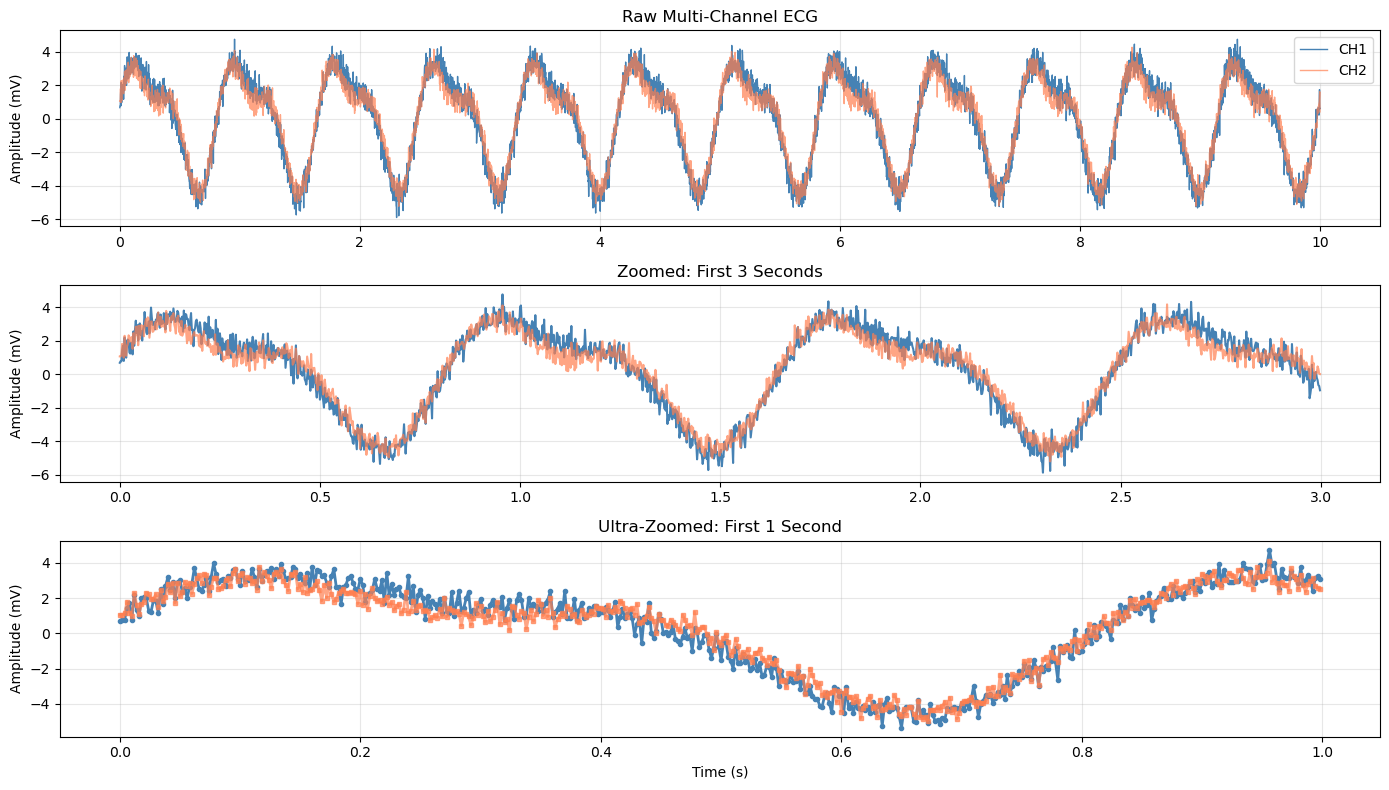

In [7]:
# Plot raw multi-channel ECG
fig, axes = plt.subplots(3, 1, figsize=(14, 8))

axes[0].plot(t, ecg_signal[:,0], linewidth=1, color='steelblue', label='CH1')
axes[0].plot(t, ecg_signal[:,1], linewidth=1, color='coral', label='CH2', alpha=0.7)
axes[0].set_ylabel('Amplitude (mV)')
axes[0].set_title('Raw Multi-Channel ECG')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

time_window = 3
axes[1].plot(t[:int(fs*time_window)], ecg_signal[:int(fs*time_window),0], linewidth=1.5, color='steelblue')
axes[1].plot(t[:int(fs*time_window)], ecg_signal[:int(fs*time_window),1], linewidth=1.5, color='coral', alpha=0.7)
axes[1].set_ylabel('Amplitude (mV)')
axes[1].set_title('Zoomed: First 3 Seconds')
axes[1].grid(True, alpha=0.3)

time_zoom = 1
axes[2].plot(t[:int(fs*time_zoom)], ecg_signal[:int(fs*time_zoom),0], linewidth=2, color='steelblue', marker='o', markersize=3)
axes[2].plot(t[:int(fs*time_zoom)], ecg_signal[:int(fs*time_zoom),1], linewidth=2, color='coral', marker='s', markersize=3, alpha=0.7)
axes[2].set_xlabel('Time (s)'); axes[2].set_ylabel('Amplitude (mV)')
axes[2].set_title('Ultra-Zoomed: First 1 Second')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/plots/01_raw_ecg_signal.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Load ECG from database when available, else synthetic fallback
np.random.seed(42)
fs = 500
duration = 10

db_path = Path('../data/processed/neuro_genomic.db')
loaded_from = 'synthetic'

if db_path.exists():
    try:
        with sqlite3.connect(db_path) as conn:
            tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)['name'].tolist()

            # Option 1: Use raw ECG table directly (expected columns: time_s, ch1, ch2)
            if 'raw_ecg' in tables:
                raw_df = pd.read_sql_query('SELECT * FROM raw_ecg', conn)
                if {'time_s', 'ch1', 'ch2'}.issubset(raw_df.columns):
                    t = raw_df['time_s'].values
                    ecg_signal = raw_df[['ch1', 'ch2']].to_numpy()
                    fs = int(raw_df['fs'].iloc[0]) if 'fs' in raw_df.columns else fs
                    duration = float(t[-1] - t[0]) if len(t) > 1 else duration
                    loaded_from = 'database table: raw_ecg'

            # Option 2: Build mixed channels from separated components table
            elif 'separated_components' in tables:
                sep_df = pd.read_sql_query('SELECT * FROM separated_components', conn)
                if {'time_s', 'maternal_ecg', 'fetal_ecg'}.issubset(sep_df.columns):
                    t = sep_df['time_s'].values
                    maternal_ecg = sep_df['maternal_ecg'].values
                    fetal_ecg = sep_df['fetal_ecg'].values
                    mixed_ch1 = 0.7 * maternal_ecg + 0.5 * fetal_ecg + 0.4 * np.random.randn(len(t))
                    mixed_ch2 = 0.6 * maternal_ecg + 0.6 * fetal_ecg + 0.3 * np.random.randn(len(t))
                    ecg_signal = np.column_stack([mixed_ch1, mixed_ch2])
                    duration = float(t[-1] - t[0]) if len(t) > 1 else duration
                    loaded_from = 'database table: separated_components (remixed)'
    except Exception:
        pass

# Synthetic fallback
if loaded_from == 'synthetic':
    t = np.linspace(0, duration, int(fs * duration), endpoint=False)

    maternal_base = 5 * np.sin(2 * np.pi * 1.2 * t)
    maternal_ecg = maternal_base + 0.3 * np.random.randn(len(t))

    fetal_base = 2.5 * np.sin(2 * np.pi * 2.4 * t + np.pi/4)
    fetal_ecg = fetal_base + 0.2 * np.random.randn(len(t))

    mixed_ch1 = 0.7 * maternal_ecg + 0.5 * fetal_ecg + 0.4 * np.random.randn(len(t))
    mixed_ch2 = 0.6 * maternal_ecg + 0.6 * fetal_ecg + 0.3 * np.random.randn(len(t))
    ecg_signal = np.column_stack([mixed_ch1, mixed_ch2])

print(f'Loaded source: {loaded_from}')
print(f'ECG shape: {ecg_signal.shape}  |  duration={duration:.2f}s  fs={fs}Hz')
print(f'CH1 mean={ecg_signal[:,0].mean():.3f}  std={ecg_signal[:,0].std():.3f}')
print(f'CH2 mean={ecg_signal[:,1].mean():.3f}  std={ecg_signal[:,1].std():.3f}')

Loaded source: synthetic
ECG shape: (5000, 2)  |  duration=10.00s  fs=500Hz
CH1 mean=0.004  std=2.660
CH2 mean=0.005  std=2.408


In [9]:
# Plot style setup
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

print('Plot style configured.')

Plot style configured.


In [10]:
# Install required packages
import subprocess, sys

packages = ['wfdb', 'biosppy', 'scikit-learn', 'scipy', 'numpy', 'pandas',
            'matplotlib', 'plotly', 'seaborn']

for package in packages:
    try:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])
    except Exception:
        pass

print("Packages installed.")

Packages installed.


In [11]:
# Optional: Google Colab drive mount
# from google.colab import drive
# drive.mount('/content/drive')
print("Runtime environment initialized")

Runtime environment initialized
